In [2]:
!pip install scikit-allel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.0 MB/s eta 0:00:0000:0100:01


In [1]:

!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz

!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi


!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel
!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.ped

!wget https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20250704.ALL.ped

print("All main raw files successfully downloaded into Kaggle!")

--2026-10-02 12:12:18--  https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecting to ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)|193.62.193.167|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1165011543 (1.1G) [application/x-gzip]
Saving to: ‘ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz’

ALL.chr1.phase3_sha 100%[===================>]   1.08G  11.1MB/s    in 4m 34s  

2026-10-02 12:16:53 (4.06 MB/s) - ‘ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz’ saved [1165011543/1165011543]

--2026-10-02 12:16:53--  https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecti

# **Stolen database created for hacker**

In [3]:
import pandas as pd
import numpy as np
import allel

vcf_file = "/kaggle/working/ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
panel_file = "/kaggle/working/integrated_call_samples_v3.20130502.ALL.panel"

print("Reading demographic data...")
public_info = pd.read_csv(
    panel_file, 
    sep='\t', 
    usecols=[0, 1, 2, 3], 
    names=['Sample_ID', 'Population', 'Super_Population', 'Gender']
)

print("Reading a small region of Chromosome 1 using the index file...")

callset = allel.read_vcf(vcf_file, fields=['samples', 'calldata/GT'], region='1:1-500000')

samples = callset['samples']


genotypes = allel.GenotypeArray(callset['calldata/GT'][:50])

# Convert the DNA data into simple numbers (0, 1, or 2 alternate alleles per marker)
snp_counts = genotypes.to_n_alt().T  # Shape: (2504 people, 50 markers)

# Create column names for the 50 DNA markers
marker_columns = [f"SNP_{i+1}" for i in range(50)]
dna_dataframe = pd.DataFrame(snp_counts, columns=marker_columns)
dna_dataframe['Sample_ID'] = samples

# Merge the demographics and the 50 DNA markers into the complete Public Database
public_database = pd.merge(public_info, dna_dataframe, on='Sample_ID')

# Save the full Public Database (all 2,504 people) permanently to Kaggle
public_database.to_csv("clean_public_database.csv", index=False)
print("Saved: clean_public_database.csv (2,504 people with 50 DNA markers each)")

# 2. Build the Stolen Database (slice of 500 people with hidden identities)
stolen_slice = public_database.iloc[:500].copy()

# Hide real names under anonymous labels for the simulation
stolen_slice['Hidden_ID'] = [f"Unknown_Person_{i+1}" for i in range(len(stolen_slice))]
stolen_slice['True_ID_For_Checking_Later'] = stolen_slice['Sample_ID']

# Remove the real Sample_ID from the stolen view so the hacker cannot see it
stolen_database = stolen_slice.drop(columns=['Sample_ID'])

# Save the Stolen Database permanently to Kaggle
stolen_database.to_csv("stolen_target_database.csv", index=False)
print("Saved: stolen_target_database.csv (500 stolen anonymous profiles)")

Reading demographic data...
Reading a small region of Chromosome 1 using the index file...


/usr/local/lib/python3.12/dist-packages/allel/io/vcf_read.py:1042: UserWarning: tabix not found, falling back to scanning to region
  warnings.warn('tabix not found, falling back to scanning to region')


Saved: clean_public_database.csv (2,504 people with 50 DNA markers each)
Saved: stolen_target_database.csv (500 stolen anonymous profiles)


In [5]:
import pandas as pd


public_db = pd.read_csv("clean_public_database.csv")
stolen_db = pd.read_csv("stolen_target_database.csv")

print("Files loaded successfully from disk.")
print(f"Public registry contains: {len(public_db)} records")
print(f"Stolen target list contains: {len(stolen_db)} records")

Files loaded successfully from disk.
Public registry contains: 2504 records
Stolen target list contains: 500 records


# Linkage attack simulation 

In [6]:
results_list = []
successful_hacks = 0
total_targets = len(stolen_db)

marker_cols = [f"SNP_{i+1}" for i in range(50)]

print("Starting genomic linkage attack...")

for index, target in stolen_db.iterrows():
    # 1. Hacker takes the known demographic clues
    clue_gender = target['Gender']
    clue_pop = target['Population']
    
    # 2. Narrow down by demographic clues first
    candidates = public_db[
        (public_db['Gender'] == clue_gender) & 
        (public_db['Population'] == clue_pop)
    ]
    
    # 3. Hacker matches the 50 DNA markers against the candidates
    target_markers = target[marker_cols].values
    candidate_markers = candidates[marker_cols].values
    
    # Check which candidate matches all 50 DNA markers exactly
    match_mask = (candidate_markers == target_markers).all(axis=1)
    matched_candidates = candidates[match_mask]
    
    # 4. If exactly 1 person matches, identity is uncovered
    if len(matched_candidates) == 1:
        guessed_id = matched_candidates.iloc[0]['Sample_ID']
        is_correct = (guessed_id == target['True_ID_For_Checking_Later'])
        
        if is_correct:
            successful_hacks += 1
            
        results_list.append({
            'Hidden_ID': target['Hidden_ID'],
            'Hacker_Guessed_ID': guessed_id,
            'True_ID': target['True_ID_For_Checking_Later'],
            'Attack_Success': is_correct
        })
    else:
        # If 0 matches or multiple matches remain
        results_list.append({
            'Hidden_ID': target['Hidden_ID'],
            'Hacker_Guessed_ID': 'Failed to link',
            'True_ID': target['True_ID_For_Checking_Later'],
            'Attack_Success': False
        })

# Calculate final attack success rate
attack_success_rate = (successful_hacks / total_targets) * 100

print("\n--- ATTACK SUMMARY ---")
print(f"Total Profiles Attacked: {total_targets}")
print(f"Successfully Re-identified: {successful_hacks}")
print(f"Attack Success Rate: {attack_success_rate:.2f}%")

Starting genomic linkage attack...

--- ATTACK SUMMARY ---
Total Profiles Attacked: 500
Successfully Re-identified: 311
Attack Success Rate: 62.20%


# Result

In [8]:

results_table = pd.DataFrame(results_list)


results_table.to_csv("linkage_attack_unprotected_results.csv", index=False)

print("Saved: linkage_attack_unprotected_results.csv")
print("\nFirst 5 attack records:")
print(results_table.head())

Saved: linkage_attack_unprotected_results.csv

First 5 attack records:
          Hidden_ID Hacker_Guessed_ID  True_ID  Attack_Success
0  Unknown_Person_1           HG00096  HG00096            True
1  Unknown_Person_2           HG00097  HG00097            True
2  Unknown_Person_3           HG00099  HG00099            True
3  Unknown_Person_4    Failed to link  HG00100           False
4  Unknown_Person_5           HG00101  HG00101            True


#  Linkage Attack done

# Membership Inference Attack

**Setup and Load data**

In [10]:
import os, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score
warnings.filterwarnings("ignore")
OUT_DIR= "/kaggle/working"
RESULTS_FILE = "/kaggle/working/linkage_attack_unprotected_results.csv"


hits = glob.glob("/kaggle/working/clean_public_database.csv") + glob.glob("/kaggle/input/**/clean_public_database.csv", recursive=True)
print("Found:", hits)
df = pd.read_csv(hits[0])
print(df.shape)
df.head(3)

Found: ['/kaggle/working/clean_public_database.csv', '/kaggle/input/datasets/adnanborshon246/genome-privacy-outputs/Outputs/Linkage attack outputs/clean_public_database.csv']
(2504, 54)


,Sample_ID,Population,Super_Population,Gender,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,...,SNP_41,SNP_42,SNP_43,SNP_44,SNP_45,SNP_46,SNP_47,SNP_48,SNP_49,SNP_50
0,HG00096,GBR,EUR,male,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,HG00097,GBR,EUR,female,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,HG00099,GBR,EUR,female,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## Pick SNP columns and the label

In [13]:

LABEL_COL = "Super_Population"
META_COLS = ["Sample_ID", "Population", "Super_Population", "Gender"]

meta_present = [c for c in META_COLS if c in df.columns]
snp_cols = [c for c in df.columns if c not in meta_present and pd.api.types.is_numeric_dtype(df[c])]
print("SNP columns found:", len(snp_cols), "(expected 50)")
print("Label classes:", df[LABEL_COL].value_counts().to_dict())

X = df[snp_cols].values.astype(float)
y = df[LABEL_COL].values
assert not np.isnan(X).any(), "Missing values found. Fill them first (for example with 0)."

SNP columns found: 50 (expected 50)
Label classes: {'AFR': 661, 'EAS': 504, 'EUR': 503, 'SAS': 489, 'AMR': 347}


## Split into 4 groups

| Group | Who uses it | Meaning |
|---|---|---|
| target_in | hospital | **members** (used to train the target model) |
| target_out | nobody | **non-members** (for testing the attack) |
| shadow_in | attacker | attacker's pretend members |
| shadow_out | attacker | attacker's pretend non-members |


In [16]:
def four_way_split(X, y, seed):
    Xt, Xs, yt, ys = train_test_split(X, y, test_size=0.5, stratify=y, random_state=seed)
    t_in_X, t_out_X, t_in_y, t_out_y = train_test_split(Xt, yt, test_size=0.5, stratify=yt, random_state=seed)
    s_in_X, s_out_X, s_in_y, s_out_y = train_test_split(Xs, ys, test_size=0.5, stratify=ys, random_state=seed)
    n = min(len(t_in_X), len(t_out_X), len(s_in_X), len(s_out_X))   # make all groups equal size
    return {
        "t_in": (t_in_X[:n], t_in_y[:n]), "t_out": (t_out_X[:n], t_out_y[:n]),
        "s_in": (s_in_X[:n], s_in_y[:n]), "s_out": (s_out_X[:n], s_out_y[:n]),
    }

g = four_way_split(X, y, seed=42)
print({k: v[0].shape[0] for k, v in g.items()})

{'t_in': 626, 't_out': 626, 's_in': 626, 's_out': 626}


# Target model and shadow model

In [18]:
def make_model(seed=0):
    # The hospital's model. Later, defenses will swap this function (for example diffprivlib).
    return RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1)

seed = 42
target = make_model(seed).fit(*g["t_in"])
shadow = make_model(seed + 1).fit(*g["s_in"])

for name, m, tr, te in [("TARGET", target, g["t_in"], g["t_out"]), ("SHADOW", shadow, g["s_in"], g["s_out"])]:
    tr_acc = accuracy_score(tr[1], m.predict(tr[0]))
    te_acc = accuracy_score(te[1], m.predict(te[0]))
    print(f"{name}: train acc = {tr_acc:.3f} | test acc = {te_acc:.3f} | gap = {tr_acc - te_acc:.3f}")

TARGET: train acc = 0.647 | test acc = 0.387 | gap = 0.260
SHADOW: train acc = 0.682 | test acc = 0.411 | gap = 0.272


# Build the attack model

In [19]:
def attack_features(model, Xd, yd):
    proba = model.predict_proba(Xd)
    classes = list(model.classes_)
    y_idx = np.array([classes.index(v) for v in yd])
    eps = 1e-12
    p_true = proba[np.arange(len(yd)), y_idx]
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    loss = -np.log(p_true + eps)
    entropy = -(proba * np.log(proba + eps)).sum(axis=1)
    correct = (proba.argmax(axis=1) == y_idx).astype(float)
    return np.column_stack([sorted_p, p_true, loss, entropy, correct])

def build_attack_data(model, members, nonmembers):
    F_in = attack_features(model, *members)
    F_out = attack_features(model, *nonmembers)
    F = np.vstack([F_in, F_out])
    lab = np.concatenate([np.ones(len(F_in)), np.zeros(len(F_out))])   # 1 = member, 0 = non-member
    return F, lab

# Train attack model on SHADOW data (attacker's own data)
F_shadow, lab_shadow = build_attack_data(shadow, g["s_in"], g["s_out"])
attack_model = GradientBoostingClassifier(random_state=seed).fit(F_shadow, lab_shadow)
print("Attack model trained on", len(lab_shadow), "shadow examples")

Attack model trained on 1252 shadow examples


# Attack the real target and measure

attack_accuracy   : 0.6398
auc               : 0.6868
precision         : 0.6582
recall            : 0.5815
tpr_at_1pct_fpr   : 0.0128
advantage         : 0.2796


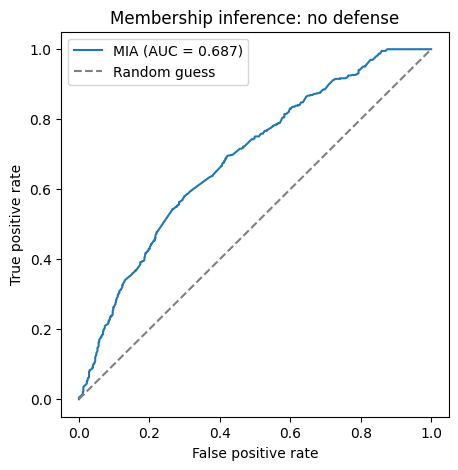

In [21]:
def evaluate_attack(attack_model, F, lab):
    score = attack_model.predict_proba(F)[:, 1]
    pred = (score >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(lab, score)
    tpr_at_1 = float(np.interp(0.01, fpr, tpr))
    return {
        "attack_accuracy": accuracy_score(lab, pred),
        "auc": roc_auc_score(lab, score),
        "precision": precision_score(lab, pred, zero_division=0),
        "recall": recall_score(lab, pred, zero_division=0),
        "tpr_at_1pct_fpr": tpr_at_1,
        "advantage": float(recall_score(lab, pred) - pred[lab == 0].mean()),   # TPR - FPR
    }, fpr, tpr
OUT_DIR= "/kaggle/working"
F_target, lab_target = build_attack_data(target, g["t_in"], g["t_out"])
metrics, fpr, tpr = evaluate_attack(attack_model, F_target, lab_target)
for k, v in metrics.items():
    print(f"{k:18s}: {v:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MIA (AUC = {metrics['auc']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Membership inference: no defense"); plt.legend()
plt.savefig(f"{OUT_DIR}/mia_roc_no_defense.png", dpi=150, bbox_inches="tight")
plt.show()

# Sanity check

In [23]:
def threshold_attack(F, lab):
    p_true = F[:, -4]   # column: probability of the true label
    fpr, tpr, _ = roc_curve(lab, p_true)
    auc = roc_auc_score(lab, p_true)
    best_acc = max(((tpr + (1 - fpr)) / 2))
    return {"attack_accuracy": float(best_acc), "auc": float(auc)}

thr = threshold_attack(F_target, lab_target)
print("Threshold attack:", thr)

Threshold attack: {'attack_accuracy': 0.6453674121405751, 'auc': 0.6923644213986057}


# Repeat with 5 random splits

In [24]:
def run_full_mia(make_model_fn, seeds=(1, 2, 3, 4, 5)):
    rows = []
    for s in seeds:
        gg = four_way_split(X, y, seed=s)
        tgt = make_model_fn(s).fit(*gg["t_in"])
        shd = make_model_fn(s + 100).fit(*gg["s_in"])
        F_s, l_s = build_attack_data(shd, gg["s_in"], gg["s_out"])
        am = GradientBoostingClassifier(random_state=s).fit(F_s, l_s)
        F_t, l_t = build_attack_data(tgt, gg["t_in"], gg["t_out"])
        m, _, _ = evaluate_attack(am, F_t, l_t)
        m["target_train_acc"] = accuracy_score(gg["t_in"][1], tgt.predict(gg["t_in"][0]))
        m["target_test_acc"] = accuracy_score(gg["t_out"][1], tgt.predict(gg["t_out"][0]))   # utility of the model
        m["seed"] = s
        rows.append(m)
    return pd.DataFrame(rows)

runs = run_full_mia(make_model)
display(runs.round(4))
summary = runs.drop(columns="seed").agg(["mean", "std"]).round(4)
display(summary)

,attack_accuracy,auc,precision,recall,tpr_at_1pct_fpr,advantage,target_train_acc,target_test_acc,seed
0,0.6573,0.7012,0.6743,0.6086,0.0367,0.3147,0.6677,0.4233,1
1,0.6382,0.7016,0.6733,0.5367,0.0404,0.2764,0.6645,0.4089,2
2,0.6438,0.6760,0.6751,0.5543,0.0180,0.2875,0.6502,0.4217,3
3,0.6254,0.6888,0.6554,0.5288,0.0531,0.2508,0.6454,0.4042,4
4,0.6254,0.6786,0.6319,0.6006,0.0277,0.2508,0.6470,0.3962,5


,attack_accuracy,auc,precision,recall,tpr_at_1pct_fpr,advantage,target_train_acc,target_test_acc
mean,0.6380,0.6892,0.6620,0.5658,0.0352,0.2760,0.6550,0.4109
std,0.0135,0.0121,0.0187,0.0367,0.0133,0.0269,0.0104,0.0116


# MIA Result

In [26]:
COLS = ["timestamp", "attack", "defense", "attack_accuracy", "auc", "tpr_at_1pct_fpr",
        "advantage", "target_test_acc", "n_runs", "notes"]
OUT_DIR= "/kaggle/working"
def save_result(attack, defense, attack_accuracy, auc=None, tpr_at_1pct_fpr=None,
                advantage=None, target_test_acc=None, n_runs=1, notes=""):
    row = {"timestamp": time.strftime("%Y-%m-%d %H:%M:%S"), "attack": attack, "defense": defense,
           "attack_accuracy": attack_accuracy, "auc": auc, "tpr_at_1pct_fpr": tpr_at_1pct_fpr,
           "advantage": advantage, "target_test_acc": target_test_acc, "n_runs": n_runs, "notes": notes}
    new = pd.DataFrame([row], columns=COLS)
    if os.path.exists(RESULTS_FILE):
        new = pd.concat([pd.read_csv(RESULTS_FILE), new], ignore_index=True)
    new.to_csv(RESULTS_FILE, index=False)

# 1) Linkage attack result from Step 1 (so everything is in one place)
save_result("Linkage", "none", attack_accuracy=0.6220, n_runs=1,
            notes="311/500 re-identified using 50 SNPs + gender + country")

# 2) Membership inference, no defense
mean = runs.mean(numeric_only=True)
save_result("MembershipInference", "none",
            attack_accuracy=mean["attack_accuracy"], auc=mean["auc"],
            tpr_at_1pct_fpr=mean["tpr_at_1pct_fpr"], advantage=mean["advantage"],
            target_test_acc=mean["target_test_acc"], n_runs=len(runs),
            notes="RandomForest(200) target, GradientBoosting attack, shadow-model attack, 5 splits")

# 3) Simple threshold baseline
save_result("MIA_threshold_baseline", "none", attack_accuracy=thr["attack_accuracy"], auc=thr["auc"], n_runs=1)

# 4) Also save the detailed 5-run table (not only the mean)
runs.to_csv(f"{OUT_DIR}/mia_runs_no_defense.csv", index=False)
summary.to_csv(f"{OUT_DIR}/mia_summary_no_defense.csv")

print("Files saved in", OUT_DIR, ":", sorted(os.listdir(OUT_DIR)))
display(pd.read_csv(RESULTS_FILE))

Files saved in /kaggle/working : ['.virtual_documents', 'ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz', 'ALL.chr1.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi', 'clean_public_database.csv', 'integrated_call_samples_v3.20130502.ALL.panel', 'integrated_call_samples_v3.20250704.ALL.ped', 'linkage_attack_unprotected_results.csv', 'mia_roc_no_defense.png', 'mia_runs_no_defense.csv', 'mia_summary_no_defense.csv', 'stolen_target_database.csv']


,Hidden_ID,Hacker_Guessed_ID,True_ID,Attack_Success,timestamp,attack,defense,attack_accuracy,auc,tpr_at_1pct_fpr,advantage,target_test_acc,n_runs,notes
0,Unknown_Person_1,HG00096,HG00096,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Unknown_Person_2,HG00097,HG00097,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unknown_Person_3,HG00099,HG00099,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unknown_Person_4,Failed to link,HG00100,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unknown_Person_5,HG00101,HG00101,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,Unknown_Person_499,HG01495,HG01495,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499,Unknown_Person_500,HG01497,HG01497,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500,NaN,NaN,NaN,NaN,2026-10-02 12:37:08,Linkage,none,0.622000,NaN,NaN,NaN,NaN,1.0,311/500 re-identified using 50 SNPs + gender +...
501,NaN,NaN,NaN,NaN,2026-10-02 12:37:08,MembershipInference,none,0.638019,0.689237,0.035177,0.276038,0.410863,5.0,"RandomForest(200) target, GradientBoosting att..."


# Privacy Methods


**Differential Privacy**

In [27]:
pip install diffprivlib sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 3.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.9/259.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.9 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


# Differential Privacy Defense

In [34]:
import pandas as pd
import numpy as np
import time
import os
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier

RESULTS_FILE = "/kaggle/working/final_defense_dashboard.csv"

def save_defense_result(attack_name, defense_name, attack_accuracy):
    row = pd.DataFrame([{
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "attack_type": attack_name,
        "defense_applied": defense_name,
        "hacker_success_rate": float(attack_accuracy)
    }])
    if os.path.exists(RESULTS_FILE):
        row = pd.concat([pd.read_csv(RESULTS_FILE), row], ignore_index=True)
    row.to_csv(RESULTS_FILE, index=False)
    print(f"Saved result: {defense_name}")

print("--- 1. TESTING DIFFERENTIAL PRIVACY ---")

# We tell the tool that for all 50 columns, the absolute minimum is 0, and the absolute maximum is 2.
# This completely stops the PrivacyLeakWarning.
feature_bounds = ([0] * 50, [2] * 50)

# We add the bounds=feature_bounds rule to the target model
dp_target = DPRandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    epsilon=1.0, 
    classes=['AFR', 'EAS', 'EUR', 'SAS', 'AMR'],
    bounds=feature_bounds
)

dp_target.fit(*g["t_in"])

shadow = RandomForestClassifier(n_estimators=200, random_state=43, n_jobs=-1).fit(*g["s_in"])
F_shadow, lab_shadow = build_attack_data(shadow, g["s_in"], g["s_out"])
attack_model = GradientBoostingClassifier(random_state=42).fit(F_shadow, lab_shadow)

F_dp, lab_dp = build_attack_data(dp_target, g["t_in"], g["t_out"])
dp_metrics, _, _ = evaluate_attack(attack_model, F_dp, lab_dp)

save_defense_result("Membership Inference", "Differential Privacy Only", dp_metrics['attack_accuracy'])

--- 1. TESTING DIFFERENTIAL PRIVACY ---
Saved result: Differential Privacy Only


# Synthetic Data Defense

In [35]:
print("\n--- 2. TESTING SYNTHETIC DATA ---")
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Load the real databases
public_db = pd.read_csv("clean_public_database.csv")
stolen_db = pd.read_csv("stolen_target_database.csv")

# Study the real stolen data and generate 500 fake profiles
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(stolen_db)
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(stolen_db)
synthetic_stolen_db = synthesizer.sample(num_rows=len(stolen_db))
synthetic_stolen_db['True_ID_For_Checking_Later'] = "Fake_Data" # Erase true identities

successful_hacks = 0
marker_cols = [f"SNP_{i+1}" for i in range(50)]

# The hacker attempts the Linkage Attack on the Synthetic Data
for index, target in synthetic_stolen_db.iterrows():
    # Look for matching demographics in the public registry
    candidates = public_db[(public_db['Gender'] == target['Gender']) & (public_db['Population'] == target['Population'])]
    
    target_markers = target[marker_cols].values
    candidate_markers = candidates[marker_cols].values
    
    if len(candidates) > 0:
        match_mask = (candidate_markers == target_markers).all(axis=1)
        matched_candidates = candidates[match_mask]
        
        if len(matched_candidates) == 1:
            guessed_id = matched_candidates.iloc[0]['Sample_ID']
            # This will fail because guessed_id will never equal "Fake_Data"
            if guessed_id == target['True_ID_For_Checking_Later']:
                successful_hacks += 1

sd_attack_accuracy = successful_hacks / len(synthetic_stolen_db)
save_defense_result("Linkage Attack", "Synthetic Data Only", sd_attack_accuracy)


--- 2. TESTING SYNTHETIC DATA ---
Saved result: Synthetic Data Only


# Combined Double Defense

In [36]:
print("\n--- 3. TESTING COMBINED DEFENSE (SYNTHETIC + DP) ---")
# 1. Convert the hospital's private training data (t_in) into a simple table
X_t_in, y_t_in = g["t_in"]
df_t_in = pd.DataFrame(X_t_in, columns=[f"SNP_{i+1}" for i in range(X_t_in.shape[1])])
df_t_in['Label'] = y_t_in

# 2. Generate a Synthetic version of the hospital training data
meta_t_in = SingleTableMetadata()
meta_t_in.detect_from_dataframe(df_t_in)
syn_t_in_model = GaussianCopulaSynthesizer(meta_t_in)
syn_t_in_model.fit(df_t_in)
syn_df = syn_t_in_model.sample(num_rows=len(df_t_in))

# Separate the fake data back into features (X) and labels (y)
X_syn = syn_df.drop(columns=['Label']).values
y_syn = syn_df['Label'].values

# 3. Train the Differential Privacy Model on the FAKE Synthetic Data
# Tell the tool that for all 50 columns, the minimum is 0 and the maximum is 2.
feature_bounds = ([0] * 50, [2] * 50)

dp_syn_target = DPRandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    epsilon=1.0, 
    classes=['AFR', 'EAS', 'EUR', 'SAS', 'AMR'],
    bounds=feature_bounds
)
dp_syn_target.fit(X_syn, y_syn)

# 4. The hacker attacks the double-defended model using original real records
F_combined, lab_combined = build_attack_data(dp_syn_target, g["t_in"], g["t_out"])
combined_metrics, _, _ = evaluate_attack(attack_model, F_combined, lab_combined)

save_defense_result("Membership Inference", "Combined (DP + Synthetic)", combined_metrics['attack_accuracy'])


--- 3. TESTING COMBINED DEFENSE (SYNTHETIC + DP) ---
Saved result: Combined (DP + Synthetic)


# Final result

In [37]:
print("\n--- FINAL RESULTS DASHBOARD ---")
# Load and display the saved results
dashboard = pd.read_csv(RESULTS_FILE)

# For comparison, let's manually add your unprotected baseline results from your initial report
baseline = pd.DataFrame([
    {"timestamp": "-", "attack_type": "Membership Inference", "defense_applied": "No Defense (Baseline)", "hacker_success_rate": 0.6380},
    {"timestamp": "-", "attack_type": "Linkage Attack", "defense_applied": "No Defense (Baseline)", "hacker_success_rate": 0.6220}
])

# Combine them so you can see the difference before and after defenses
final_view = pd.concat([baseline, dashboard], ignore_index=True)
display(final_view)


--- FINAL RESULTS DASHBOARD ---


,timestamp,attack_type,defense_applied,hacker_success_rate
0,-,Membership Inference,No Defense (Baseline),0.638000
1,-,Linkage Attack,No Defense (Baseline),0.622000
2,2026-10-02 12:45:55,Membership Inference,Differential Privacy Only,0.500000
3,2026-10-02 12:47:21,Membership Inference,Differential Privacy Only,0.500000
4,2026-10-02 12:47:42,Linkage Attack,Synthetic Data Only,0.000000
5,2026-10-02 12:47:50,Membership Inference,Combined (DP + Synthetic),0.499201
6,2026-10-02 12:49:48,Membership Inference,Differential Privacy Only,0.500000
7,2026-10-02 12:49:56,Linkage Attack,Synthetic Data Only,0.000000
8,2026-10-02 12:50:37,Membership Inference,Combined (DP + Synthetic),0.500000
